In [10]:
import sys
import os
from typing import List, Dict, Tuple, Callable, Any
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
import logging
from datetime import datetime
from tdecomp.matrix.decomposer import CURDecomposition
import pandas as pd

In [7]:
import time

def run_benchmarks_cpu():
    # Явно указываем CPU
    device = torch.device('cpu')
    print(f"Using device: {device}")

    inits = [
        'l1_norm',
        'l2_norm',
        'linf_norm',
        'fro_norm', 
        'ridge_leverage',
    ]
    
    # Доли ранга от минимальной размерности
    rank_fractions = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1]
    
    results = []

    shapes_m = [4, 20, 100]
    shapes_n = [100, 1000, 10000]

    for M in shapes_m:
        for N in shapes_n:
            print(f"Benchmarking matrix shape: {M}x{N}...")
            
            # Генерация данных
            W = torch.randn(M, N, device=device)
            min_dim = min(M, N)
            
            for init_type in inits:
                try:
                    cur_model = CURDecomposition(random_init=init_type)
                except Exception as e:
                    print(f"Skipping init '{init_type}': {e}")
                    continue
                
                for r in rank_fractions:
                    
                    times = []
                    errors = []
                    
                    # Делаем 5 прогонов для усреднения
                    for _ in range(5):

                        start_time = time.perf_counter()
                        
                        factors = cur_model.decompose(W, rank=r)
   
                        end_time = time.perf_counter()
                        
                        elapsed_ms = (end_time - start_time) * 1000
                        times.append(elapsed_ms)
                        
                        # Расчет ошибки (Relative Frobenius Norm)
                        C, U, R = factors
                        approx_matrix = C @ U @ R
                        diff = W - approx_matrix
                        error_norm = torch.linalg.norm(diff, ord=2)
                        initial_norm = torch.linalg.norm(W, ord=2)
                        error = error_norm / (initial_norm + 1e-7)
                        
                        error = cur_model.get_approximation_error(W, *factors)
                        errors.append(error.item())
                    
                    # Сохраняем результаты
                    results.append({
                        "M": M,
                        "N": N,
                        "Init": init_type,
                        "Rank": r,
                        "Avg_Time_ms": sum(times) / len(times),
                        "Avg_Error": sum(errors) / len(errors)
                    })

    return pd.DataFrame(results)


In [ ]:
df_results = run_benchmarks_cpu()
df_results

In [11]:
def run_benchmarks_gpu():
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available! Please check your GPU installation.")

    device = torch.device('cuda')
    print(f"Using device: {device} ({torch.cuda.get_device_name(0)})")

    inits = [
        'l1_norm',
        'l2_norm',
        'linf_norm',
        'fro_norm',
        'ridge_leverage',
    ]
    
    # Доли ранга от минимальной размерности
    rank_fractions = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
    
    results = []

    shapes_m = [4, 20, 100]
    shapes_n = [100, 1000, 10000]

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    for M in shapes_m:
        for N in shapes_n:
            print(f"Benchmarking matrix shape: {M}x{N}...")

            W = torch.randn(M, N, device=device)
            
            for init_type in inits:
                try:
                    cur_model = CURDecomposition(random_init=init_type)
                except Exception as e:
                    print(f"Skipping init '{init_type}': {e}")
                    continue
                
                for r_frac in rank_fractions:
                    
                    times = []
                    errors = []
                    
                    # 25 прогонов для усреднения
                    for _ in range(25):

                        torch.cuda.synchronize() 
                        start_event.record()
                    
                        factors = cur_model.decompose(W, rank=r_frac)
                        
                        end_event.record()
                        end_event.synchronize()
                        elapsed_ms = start_event.elapsed_time(end_event)
                        times.append(elapsed_ms)
                        

                        error = cur_model.get_approximation_error(W, *factors)
                        errors.append(error.item())
                    
                    # Сохраняем результаты
                    results.append({
                        "M": M,
                        "N": N,
                        "Init": init_type,
                        "Rank_Fraction": r_frac,
                        "Avg_Time_ms": sum(times) / len(times),
                        "Avg_Error": sum(errors) / len(errors)
                    })
            
            # Очищаем память после обработки одной матрицы
            del W
            torch.cuda.empty_cache()

    return pd.DataFrame(results)


In [8]:
df_results = run_benchmarks_gpu()
df_results

Using device: cuda (NVIDIA GeForce RTX 3060 Laptop GPU)
Benchmarking matrix shape: 4x100...
Benchmarking matrix shape: 4x1000...
Benchmarking matrix shape: 4x10000...
Benchmarking matrix shape: 20x100...
Benchmarking matrix shape: 20x1000...
Benchmarking matrix shape: 20x10000...
Benchmarking matrix shape: 100x100...
Benchmarking matrix shape: 100x1000...
Benchmarking matrix shape: 100x10000...


,M,N,Init,Rank_Fraction,Avg_Time_ms,Avg_Error
0,4,100,l1_norm,0.50,1.627676,1.464168
1,4,100,l1_norm,0.60,1.345665,1.464168
2,4,100,l1_norm,0.70,1.307798,1.464168
3,4,100,l1_norm,0.80,1.707820,0.723209
4,4,100,l1_norm,0.90,1.916166,0.723209
...,...,...,...,...,...,...
310,100,10000,ridge_leverage,0.70,4.518840,206.288147
311,100,10000,ridge_leverage,0.80,4.848173,3.591306
312,100,10000,ridge_leverage,0.90,5.243286,4.307717
313,100,10000,ridge_leverage,0.95,4.593678,1.262749


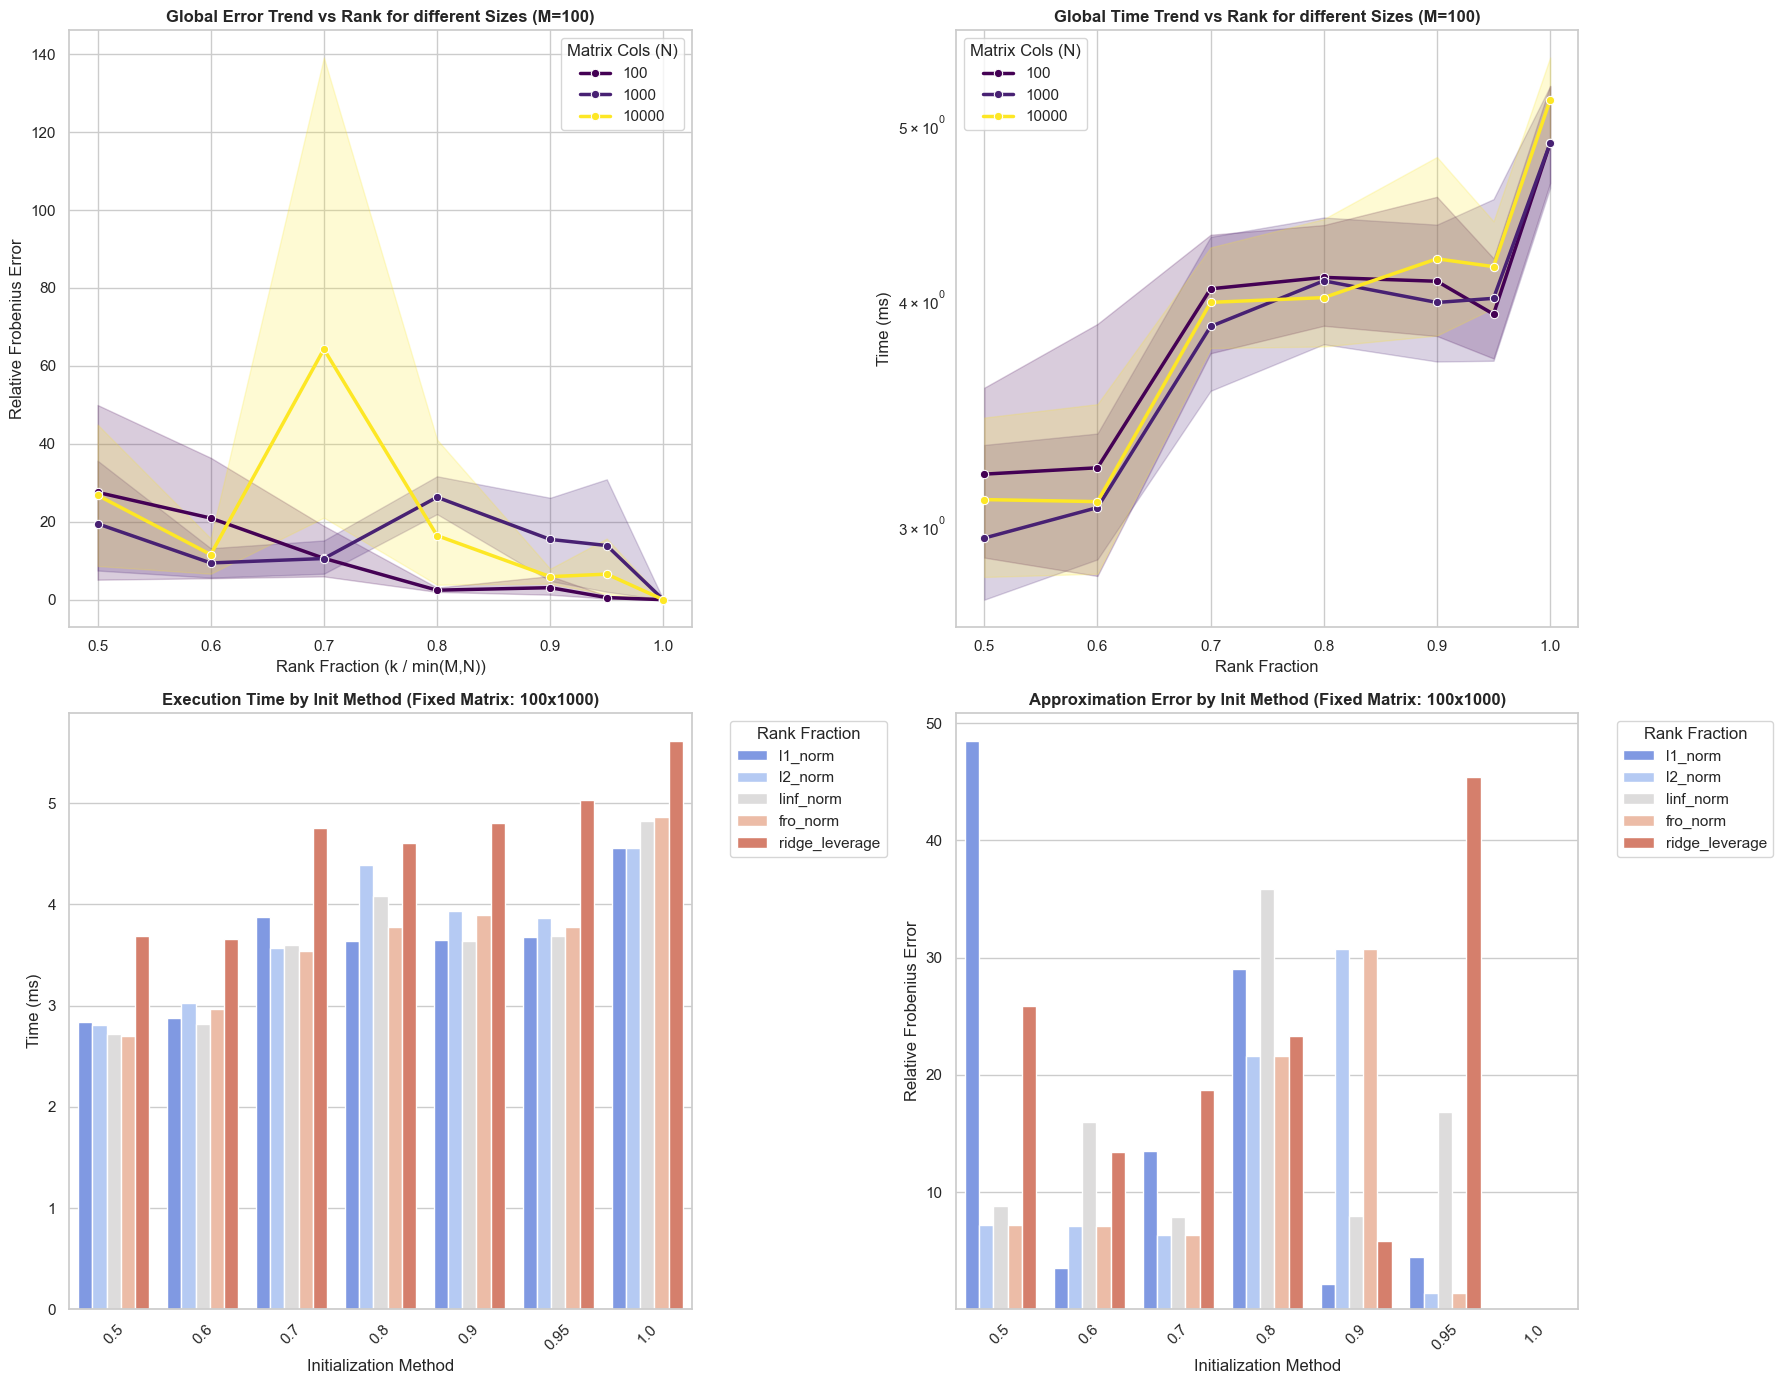

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Предполагаем, что df_results уже существует
df = df_results.copy()

# Настройка стиля
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- Подготовка данных ---
# Найдем доступные размеры
available_M = sorted(df['M'].unique())
available_N = sorted(df['N'].unique())

# 1. Данные для ВЕРХНИХ графиков (Разные размеры N, фиксированное M)
# Берем максимальное M, чтобы было интереснее (или среднее)
target_M_top = available_M[-1] # Например, 100
df_scaling = df[df['M'] == target_M_top]

# 2. Данные для НИЖНИХ графиков (Фиксированная матрица среднего размера)
# Пытаемся найти "среднюю" матрицу (например, M=20, N=1000)
mid_M = available_M[len(available_M)//2] if len(available_M) > 1 else available_M[0]
mid_N = available_N[len(available_N)//2] if len(available_N) > 1 else available_N[0]


mid_M, mid_N = 100, 1000

df_methods = df[(df['M'] == mid_M) & (df['N'] == mid_N)]
title_suffix_methods = f'(Fixed Matrix: {mid_M}x{mid_N})'


# ==========================================
# ВЕРХНИЙ РЯД: Зависимость от Размера (N)
# ==========================================

# --- 1. Ошибка от Ранга (разные N) ---
# X: Rank_Fraction, Y: Error, Hue: N
# Примечание: Мы усредняем по всем Init методам, чтобы показать общий тренд масштабирования.
# Линии показывают среднее, тень - доверительный интервал (разброс между методами init).
sns.lineplot(
    ax=axes[0, 0], data=df_scaling,
    x='Rank_Fraction', y='Avg_Error', hue='N',
    palette='viridis', marker='o', linewidth=2.5
)
axes[0, 0].set_title(f'Global Error Trend vs Rank for different Sizes (M={target_M_top})', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Relative Frobenius Error')
axes[0, 0].set_xlabel('Rank Fraction (k / min(M,N))')
axes[0, 0].legend(title='Matrix Cols (N)')


# --- 2. Время от Ранга (разные N) ---
# X: Rank_Fraction, Y: Time, Hue: N
sns.lineplot(
    ax=axes[0, 1], data=df_scaling,
    x='Rank_Fraction', y='Avg_Time_ms', hue='N',
    palette='viridis', marker='o', linewidth=2.5
)
axes[0, 1].set_title(f'Global Time Trend vs Rank for different Sizes (M={target_M_top})', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Time (ms)')
axes[0, 1].set_xlabel('Rank Fraction')
axes[0, 1].set_yscale('log') # Логарифм обязателен, т.к. N=10000 намного медленнее N=100
axes[0, 1].legend(title='Matrix Cols (N)')


# ==========================================
# НИЖНИЙ РЯД: Сравнение Методов Инициализации
# ==========================================

# --- 3. Время работы разных методов (Barplot) ---
# X: Init, Y: Time, Hue: Rank_Fraction
sns.barplot(
    ax=axes[1, 0], data=df_methods,
    x="Rank_Fraction", y='Avg_Time_ms', hue="Init",
    palette='coolwarm'
)
axes[1, 0].set_title(f'Execution Time by Init Method {title_suffix_methods}', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Time (ms)')
axes[1, 0].set_xlabel('Initialization Method')
axes[1, 0].tick_params(axis='x', rotation=45)
# Выносим легенду, чтобы не перекрывать столбики
axes[1, 0].legend(title='Rank Fraction', bbox_to_anchor=(1.05, 1), loc='upper left')


# --- 4. Точность разных методов (Barplot) ---
# X: Init, Y: Error, Hue: Rank_Fraction
# Здесь мы увидим, дает ли Ridge выигрыш в точности
sns.barplot(
    ax=axes[1, 1], data=df_methods,
    x="Rank_Fraction", y='Avg_Error', hue="Init",
    palette='coolwarm'
)
axes[1, 1].set_title(f'Approximation Error by Init Method {title_suffix_methods}', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Relative Frobenius Error')
axes[1, 1].set_xlabel('Initialization Method')
axes[1, 1].tick_params(axis='x', rotation=45)

# Ограничим Y снизу, если ошибки очень близки, чтобы увидеть разницу
# (опционально, можно закомментировать)
y_min = df_methods['Avg_Error'].min() * 0.9
y_max = df_methods['Avg_Error'].max() * 1.05
axes[1, 1].set_ylim(y_min, y_max)

axes[1, 1].legend(title='Rank Fraction', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
